In [37]:
import numpy as np      #Importing various libraries to perform required tasks
import cv2
import matplotlib.pyplot as plt

In [38]:
imgcat = cv2.imread(r'/content/cat_gray.jpg', cv2.IMREAD_GRAYSCALE) #Taking cat image as input. This is path to image of cat in my pc.


In [40]:
# computing the 2d fourier transform of cat input image
ftransformcat = np.fft.fft2(imgcat)


In [53]:
# Magnitude spectrum of fourier transform of cat input image
magnitude = np.abs(ftransformcat) #magnitude in normal form
magnitudeindb = 20*np.log(np.abs(ftransformcat) + 1) #Magnitude in dB

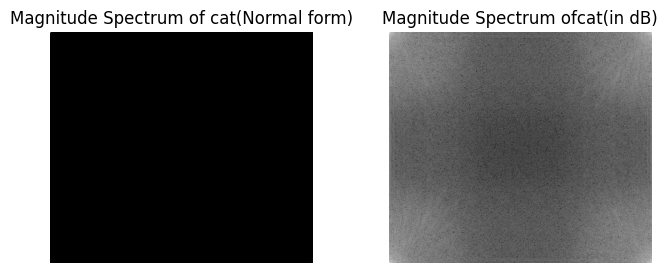

In [55]:
# Plots of magnitude
plt.figure(figsize=(8, 3))#size of image of plot formed

plt.subplot(1, 2, 1) #for getting two plots side by side as output
plt.imshow( magnitude, cmap='gray') #This is for normal form of magnitude
plt.title('Magnitude Spectrum of cat(Normal form)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitudeindb, cmap='gray') #This is for magnitude in dB
plt.title('Magnitude Spectrum ofcat(in dB)')
plt.axis('off')

plt.show()

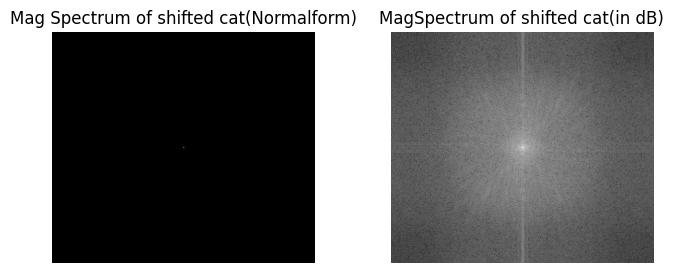

In [56]:


#Shifting cat spectrum so that low frequncies are centered
fshiftedcat = np.fft.fftshift(ftransformcat)

# Magnitude spectrum of shifted fourier transform of cat input image
magnitude = np.abs(fshiftedcat) #magnitude in normal form
magnitudeindb = 20*np.log(np.abs(fshiftedcat) + 1) #Magnitude in dB
# Plots of magnitude
plt.figure(figsize=(8, 3))#size of image of plot formed

plt.subplot(1, 2, 1) #for getting two plots side by side as output
plt.imshow( magnitude, cmap='gray') #This is for normal form of magnitude
plt.title('Mag Spectrum of shifted cat(Normalform)') #Title for shifted form
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitudeindb, cmap='gray') #This is for magnitude in dB
plt.title('MagSpectrum of shifted cat(in dB)')
plt.axis('off')

plt.show()



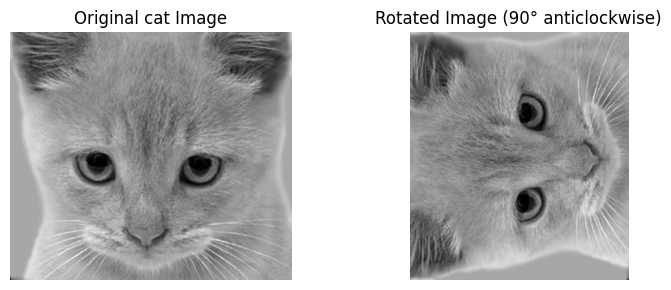

In [44]:
# Rotate image of cat 90 degrees anti-clockwise
imgrotatedcat = np.rot90(imgcat)

plt.figure(figsize=(8, 3)) #size of plot displyaed

plt.subplot(1, 2, 1) #for getting both imagees, original and rotated cat image side by side
plt.imshow(imgcat, cmap='gray') #getting both images in gray scale for easy comparison
plt.title("Original cat Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imgrotatedcat, cmap='gray')
plt.title("Rotated Image (90° anticlockwise)")
plt.axis('off')

plt.tight_layout()
plt.show()









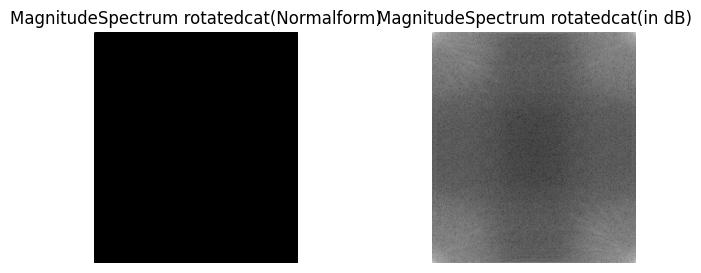

In [57]:


# Compute FFT of rotated cat image
frotcat = np.fft.fft2(imgrotatedcat)
# Magnitude spectrum of rotated image of cat
magnitude = np.abs(frotcat) #magnitude in normal form
magnitudeindb = 20*np.log(np.abs(frotcat) + 1) #Magnitude in dB
# Plots of magnitude
plt.figure(figsize=(8, 3))#size of image of plot formed

plt.subplot(1, 2, 1) #for getting two plots side by side as output
plt.imshow( magnitude, cmap='gray') #This is for normal form of magnitude
plt.title('MagnitudeSpectrum rotatedcat(Normalform)') #title which is displayed at the top
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitudeindb, cmap='gray') #This is for magnitude in dB
plt.title('MagnitudeSpectrum rotatedcat(in dB)')
plt.axis('off')

plt.show()











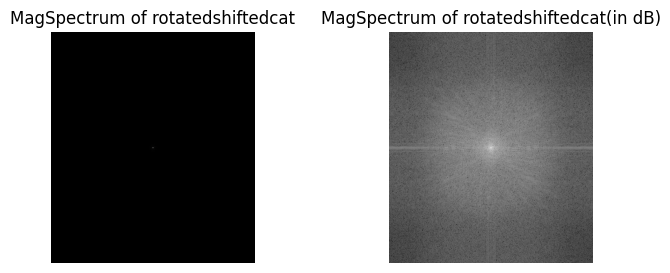

In [62]:
#Shifting spectrum so that low frequncies are centered
frotshiftcat = np.fft.fftshift(frotcat)

# Magnitude spectrum of shifted fourier transform of rotated cat input image
magnitude = np.abs(frotshiftcat) #magnitude in normal form
magnitudeindb = 20*np.log(np.abs(frotshiftcat) + 1) #Magnitude in dB
# Plots of magnitude
plt.figure(figsize=(8, 3))#size of image of plot formed

plt.subplot(1, 2, 1) #for getting two plots side by side as output
plt.imshow( magnitude, cmap='gray') #This is for normal form of magnitude
plt.title('MagSpectrum of rotatedshiftedcat')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitudeindb, cmap='gray') #This is for magnitude in dB
plt.title('MagSpectrum of rotatedshiftedcat(in dB)')
plt.axis('off')

plt.show()


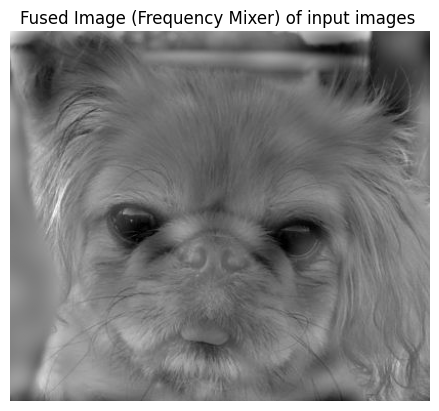

In [72]:
#Writing code for fusing both images.
# Loading input images

imgcat = cv2.imread('/content/cat_gray.jpg', cv2.IMREAD_GRAYSCALE) #This is path to cat image in my pc. Second grayscale function is to ensure that image isin grayscale mode.
imgdog = cv2.imread('/content/dog_gray.jpg', cv2.IMREAD_GRAYSCALE) #This is path to dog image in my pc.
imgcat = cv2.resize(imgcat, (imgdog.shape[1], imgdog.shape[0])) #We are changing cat image size to dog image size to ensure both images are of same size so that elment wise operations can be performed

# Computing FFTs of both images
F1cat = np.fft.fft2(imgcat) #computing fft of cat image and dog image
F2dog = np.fft.fft2(imgdog)
F1_shiftcat = np.fft.fftshift(F1cat) #Shifting low frequency components to the centre of spectrum for easy analysis
F2_shiftdog = np.fft.fftshift(F2dog)

# Creating circular low-pass and high-pass masks
heightimg , widimg = imgcat.shape #This function returns dimensions of image means its height and width or number of pixel rows (heigth) and number of columns (width)
centheight , centwid = heightimg // 2, widimg // 2 #it returns coordinates of centre of image
radius= 9
 #It is used to control how many low frequencies we want to consider


masklowpass = np.zeros((heightimg, widimg), dtype=np.float32) #lowpass filter mask
cv2.circle(masklowpass, (centwid , centheight), radius, 1, -1) #this circle is used to select low frequency region in the frequency spectrum
maskhighpass = 1 - masklowpass #High pass mask is created

# Apply masks to input images of cat and dog
Fcatlow = F1_shiftcat * masklowpass
Fdoghigh = F2_shiftdog * maskhighpass

# Combining fourier transforms of mask applied images to get fused image from it
Ffused = (Fcatlow + Fdoghigh)
Ffusedfinal = np.fft.ifftshift(Ffused) #Applying inverse shift function to so that we can get back original layout
imgfused = np.abs(np.fft.ifft2(Ffusedfinal)) #using inverse fourier transform to get fused image

# Ploting fused image
plt.imshow(imgfused, cmap='gray')
plt.title("Fused Image (Frequency Mixer) of input images ")#title of plot
plt.axis('off')
plt.show()


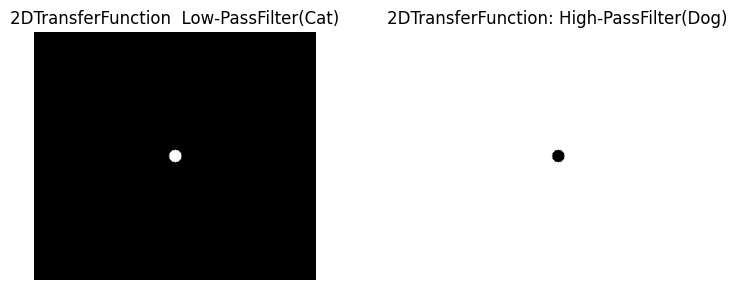

In [63]:
#Plotting plots of transfer function which are used to get fused image
plt.figure(figsize=(8, 3)) #size of plots that will be displayed

# Low-pass transfer function which used cat image as input
plt.subplot(1, 2, 1) #To get two plots side by side
plt.imshow(masklowpass, cmap='gray') #This displays low pass filter mask as grayscale image
plt.title('2DTransferFunction  Low-PassFilter(Cat)') #Title with which it is displayed
plt.axis('off')

# High-pass transfer function which used dog image as input
plt.subplot(1, 2, 2)
plt.imshow(maskhighpass, cmap='gray')
plt.title('2DTransferFunction: High-PassFilter(Dog)')
plt.axis('off')

plt.tight_layout()
plt.show()